# Notebook 06: Attention for Term-Structure Interpretability


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.linear_model import LinearRegression

from Src.Models.neural_pea import NeuralPEA, NeuralPEAWithAttention, YieldDataset
from Src.Training.losses import get_loss_fn

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## Section 1 — Data Loading & Preparation

In [2]:
# Load data
base = Path.cwd().parent / "Data" / "Processed"
features = pd.read_csv(base / "normalized_features.csv")
targets = pd.read_csv(base / "maturity_targets.csv")

# Extract columns
feat_cols = [c for c in features.columns if c != 'date']
tgt_cols = [c for c in targets.columns if c != 'date']
X, Y = features[feat_cols], targets[tgt_cols]

# Chronological split (80/20)
n_train = int(len(X) * 0.8)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
Y_train, Y_test = Y.iloc[:n_train], Y.iloc[n_train:]

print(f"Features: {len(feat_cols)}")
print(f"Maturities: {tgt_cols}")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"\nFeature names: {feat_cols}")

Features: 15
Maturities: ['y1', 'y2', 'y5', 'y10', 'y20', 'y30']
Train: 93, Test: 24

Feature names: ['cpi', 'indpro', 'unrate', 'fedfunds', 'm2', 'baa', 'aaa', 'baa10y', 'vix', 'sp500', 'd_cpi', 'd_indpro', 'd_unrate', 'd_fedfunds', 'd_m2']


## Section 2 — Training Both Models


In [3]:
class UnifiedTrainer:
    """Trainer for both base and attention models with identical protocol."""
    def __init__(self, model, lr=1e-3):
        self.model = model
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.loss_fn = get_loss_fn('mse')
        self.history = {'train_loss': [], 'val_loss': []}
    
    def _forward(self, X):
        """Handle both base and attention model outputs."""
        out = self.model(X)
        return out[0] if isinstance(out, tuple) else out
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        for X, Y in train_loader:
            self.optimizer.zero_grad()
            loss = self.loss_fn(self._forward(X), Y)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item() * len(X)
        return total_loss / len(train_loader.dataset)
    
    @torch.no_grad()
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        for X, Y in val_loader:
            total_loss += self.loss_fn(self._forward(X), Y).item() * len(X)
        return total_loss / len(val_loader.dataset)
    
    def fit(self, train_loader, val_loader, epochs=100, patience=10, verbose=True):
        best_val, wait = float('inf'), 0
        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            
            if verbose and (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")
            
            if val_loss < best_val:
                best_val, wait = val_loss, 0
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
            else:
                wait += 1
                if wait >= patience:
                    if verbose: print(f"Early stopping at epoch {epoch+1}")
                    break
        self.model.load_state_dict(self.best_state)
    
    @torch.no_grad()
    def predict(self, X):
        self.model.eval()
        X_t = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32)
        return self._forward(X_t).numpy()

In [4]:
# Create data loaders (no shuffling - chronological)
train_ds = YieldDataset(X_train, Y_train)
val_ds = YieldDataset(X_test, Y_test)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=32, shuffle=False)

# Training config (IDENTICAL for both)
config = {'epochs': 100, 'lr': 1e-3, 'patience': 10}

In [5]:
# Train Base PEA (Step 5)
print("=" * 60)
print("Training Base Neural PEA (Step 5)")
print("=" * 60)
base_model = NeuralPEA(input_dim=len(feat_cols), output_dim=len(tgt_cols), hidden_dim=64)
base_trainer = UnifiedTrainer(base_model, lr=config['lr'])
base_trainer.fit(train_loader, val_loader, epochs=config['epochs'], patience=config['patience'])

Training Base Neural PEA (Step 5)
Epoch  10 | Train: 3.320062 | Val: 9.796533
Epoch  20 | Train: 0.331887 | Val: 0.580946
Epoch  30 | Train: 0.130873 | Val: 0.174466
Early stopping at epoch 39


In [6]:
# Train Attention PEA (Step 6)
print("\n" + "=" * 60)
print("Training Attention PEA (Step 6)")
print("=" * 60)
attn_model = NeuralPEAWithAttention(input_dim=len(feat_cols), output_dim=len(tgt_cols), hidden_dim=64)
attn_trainer = UnifiedTrainer(attn_model, lr=config['lr'])
attn_trainer.fit(train_loader, val_loader, epochs=config['epochs'], patience=config['patience'])


Training Attention PEA (Step 6)
Epoch  10 | Train: 6.179932 | Val: 18.445463
Epoch  20 | Train: 5.850595 | Val: 17.346472
Epoch  30 | Train: 4.888131 | Val: 13.269741
Epoch  40 | Train: 2.456651 | Val: 3.078172
Epoch  50 | Train: 0.975069 | Val: 0.491109
Epoch  60 | Train: 0.492230 | Val: 0.157161
Epoch  70 | Train: 0.302133 | Val: 0.132453
Early stopping at epoch 77


## Section 3 — Performance Comparison

In [7]:
# Generate predictions
base_preds = base_trainer.predict(X_test)
attn_preds = attn_trainer.predict(X_test)

# Compute per-maturity MSE
Y_test_np = Y_test.values
base_mse = np.mean((base_preds - Y_test_np) ** 2, axis=0)
attn_mse = np.mean((attn_preds - Y_test_np) ** 2, axis=0)

# Results table
results = pd.DataFrame({
    'Maturity': tgt_cols,
    'Base PEA MSE': base_mse,
    'Attention PEA MSE': attn_mse,
    'Improvement (%)': ((base_mse - attn_mse) / base_mse * 100).round(1)
})

print("\n" + "=" * 70)
print("OUT-OF-SAMPLE MSE COMPARISON: Base PEA vs Attention PEA")
print("=" * 70)
print(results.to_string(index=False))
print(f"\nMean Improvement: {results['Improvement (%)'].mean():.1f}%")
print("\nPositive % = Attention model outperforms base model")


OUT-OF-SAMPLE MSE COMPARISON: Base PEA vs Attention PEA
Maturity  Base PEA MSE  Attention PEA MSE  Improvement (%)
      y1      0.418368           0.265036             36.6
      y2      0.150805           0.141279              6.3
      y5      0.046198           0.114452           -147.7
     y10      0.137655           0.074617             45.8
     y20      0.161078           0.080503             50.0
     y30      0.116469           0.095895             17.7

Mean Improvement: 1.5%

Positive % = Attention model outperforms base model


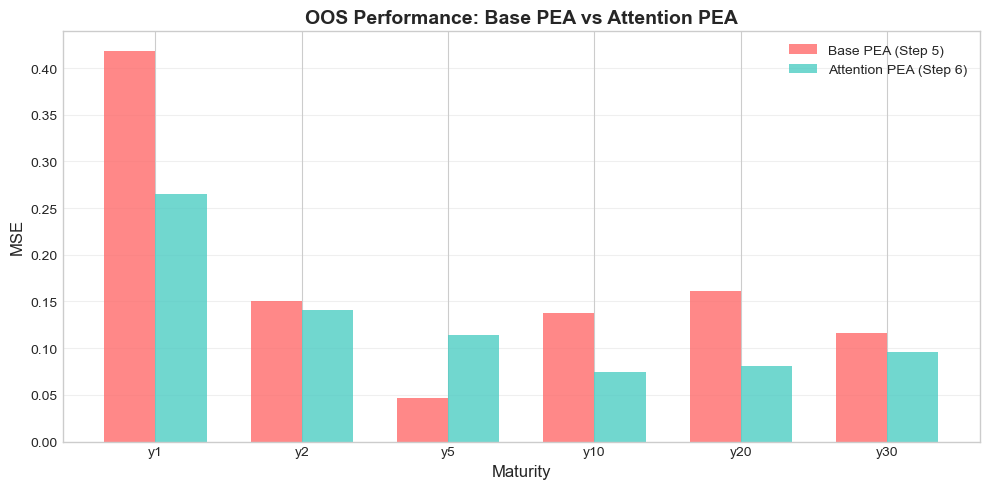

In [8]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tgt_cols))
width = 0.35

ax.bar(x - width/2, base_mse, width, label='Base PEA (Step 5)', color='#ff6b6b', alpha=0.8)
ax.bar(x + width/2, attn_mse, width, label='Attention PEA (Step 6)', color='#4ecdc4', alpha=0.8)

ax.set_xlabel('Maturity', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('OOS Performance: Base PEA vs Attention PEA', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tgt_cols)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'Reports' / 'figures' / 'pea_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Attention Weight Visualization


In [9]:
# Extract attention weights
X_tensor = torch.tensor(X_test.values, dtype=torch.float32)
attn_model.eval()
with torch.no_grad():
    _, attention = attn_model(X_tensor, return_attention=True)
    # attention: (batch, num_maturities, hidden_dim)
    avg_attention = attention.mean(dim=0).numpy()  # (num_maturities, hidden_dim)

print(f"Attention shape: {avg_attention.shape}")
print(f"Maturities: {len(tgt_cols)}, Hidden dim: {avg_attention.shape[1]}")

Attention shape: (6, 64)
Maturities: 6, Hidden dim: 64


In [ ]:
encoder_weights = attn_model.encoder[0].weight.detach().numpy()  # (hidden_dim, input_dim)
feature_attention = np.abs(avg_attention @ encoder_weights)
feature_attention = feature_attention / feature_attention.sum(axis=1, keepdims=True)
print(f"Feature attention shape: {feature_attention.shape}")

Feature attention shape: (6, 15)


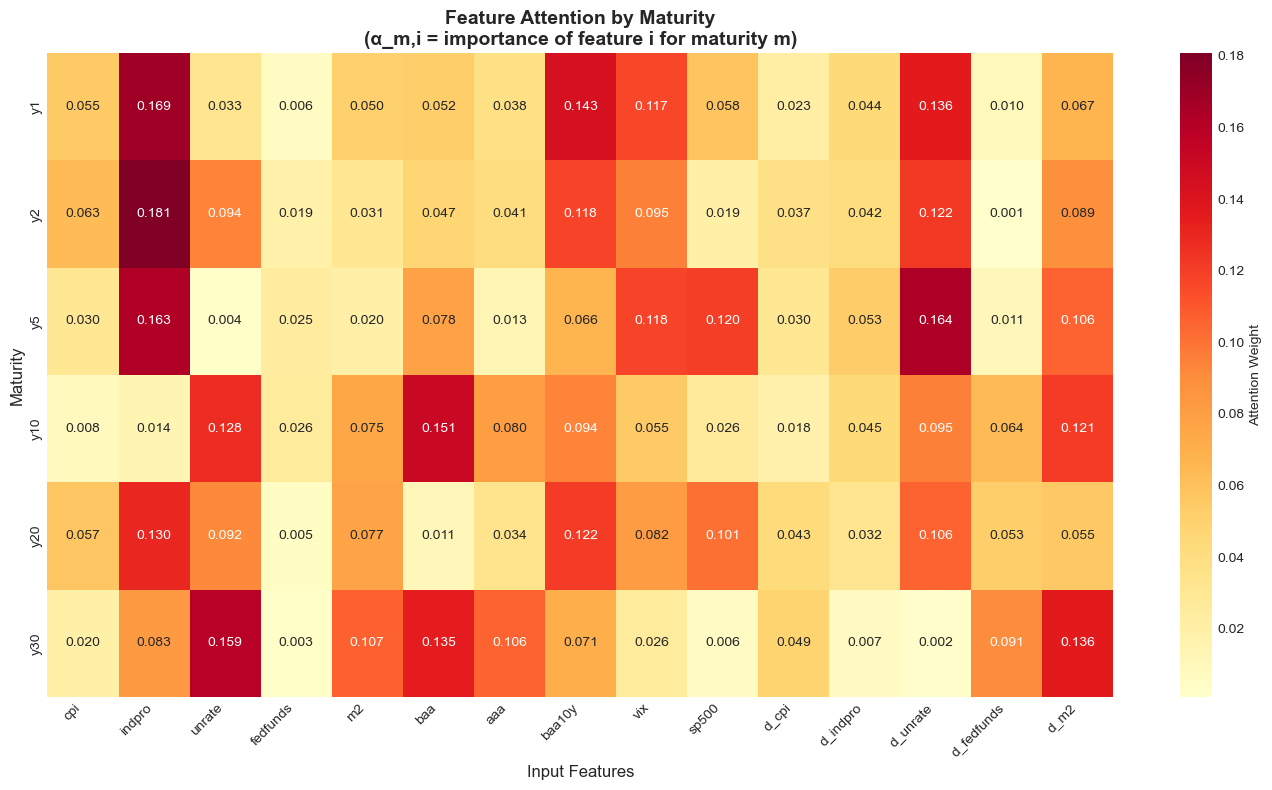

In [11]:
# Create attention heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Shorten feature names for display
short_names = [n[:20] + '...' if len(n) > 20 else n for n in feat_cols]

sns.heatmap(feature_attention, 
            xticklabels=short_names,
            yticklabels=tgt_cols,
            cmap='YlOrRd',
            annot=True,
            fmt='.3f',
            ax=ax,
            cbar_kws={'label': 'Attention Weight'})

ax.set_xlabel('Input Features', fontsize=12)
ax.set_ylabel('Maturity', fontsize=12)
ax.set_title('Feature Attention by Maturity\n(α_m,i = importance of feature i for maturity m)', 
             fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(Path.cwd().parent / 'Reports' / 'figures' / 'attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Economic Interpretation


In [12]:
# Identify top features for each maturity
print("\n" + "=" * 70)
print("TOP FEATURES BY MATURITY (Attention-Weighted)")
print("=" * 70)

for i, mat in enumerate(tgt_cols):
    top_idx = np.argsort(feature_attention[i])[::-1][:3]
    print(f"\n{mat}:")
    for j, idx in enumerate(top_idx):
        print(f"  {j+1}. {feat_cols[idx]}: {feature_attention[i, idx]:.4f}")


TOP FEATURES BY MATURITY (Attention-Weighted)

y1:
  1. indpro: 0.1690
  2. baa10y: 0.1428
  3. d_unrate: 0.1357

y2:
  1. indpro: 0.1807
  2. d_unrate: 0.1218
  3. baa10y: 0.1182

y5:
  1. d_unrate: 0.1638
  2. indpro: 0.1630
  3. sp500: 0.1202

y10:
  1. baa: 0.1508
  2. unrate: 0.1278
  3. d_m2: 0.1211

y20:
  1. indpro: 0.1298
  2. baa10y: 0.1216
  3. d_unrate: 0.1062

y30:
  1. unrate: 0.1591
  2. d_m2: 0.1356
  3. baa: 0.1346


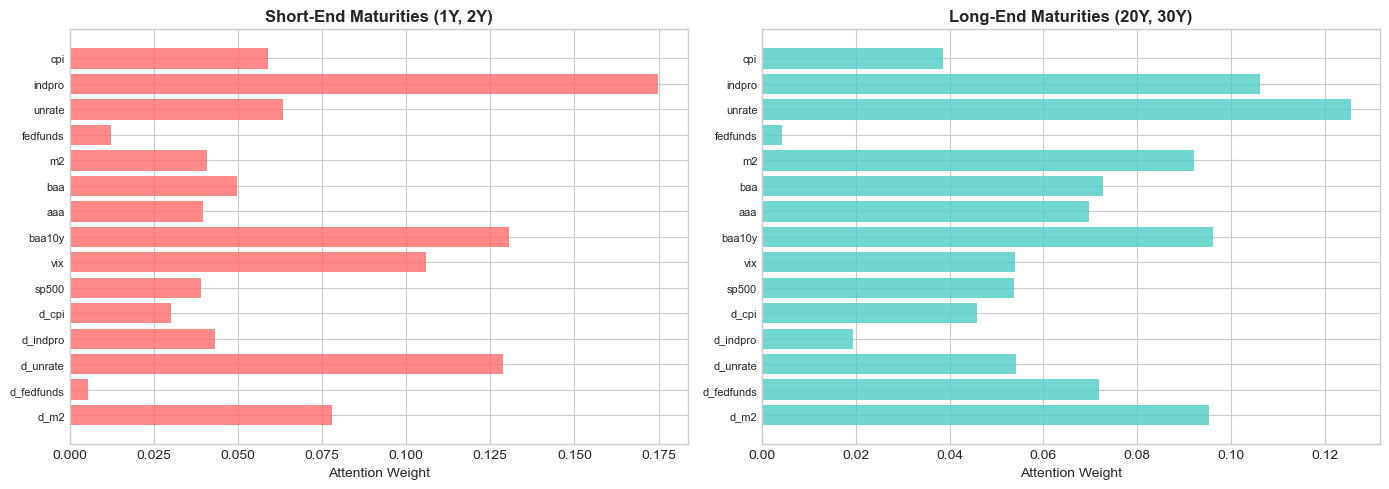

In [13]:
# Compare short vs long maturity attention patterns
short_mats = ['y1', 'y2']
long_mats = ['y20', 'y30']

short_idx = [tgt_cols.index(m) for m in short_mats if m in tgt_cols]
long_idx = [tgt_cols.index(m) for m in long_mats if m in tgt_cols]

if short_idx and long_idx:
    short_attn = feature_attention[short_idx].mean(axis=0)
    long_attn = feature_attention[long_idx].mean(axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Short end
    axes[0].barh(range(len(feat_cols)), short_attn, color='#ff6b6b', alpha=0.8)
    axes[0].set_yticks(range(len(feat_cols)))
    axes[0].set_yticklabels(short_names, fontsize=8)
    axes[0].set_xlabel('Attention Weight')
    axes[0].set_title('Short-End Maturities (1Y, 2Y)', fontweight='bold')
    axes[0].invert_yaxis()
    
    # Long end
    axes[1].barh(range(len(feat_cols)), long_attn, color='#4ecdc4', alpha=0.8)
    axes[1].set_yticks(range(len(feat_cols)))
    axes[1].set_yticklabels(short_names, fontsize=8)
    axes[1].set_xlabel('Attention Weight')
    axes[1].set_title('Long-End Maturities (20Y, 30Y)', fontweight='bold')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(Path.cwd().parent / 'Reports' / 'figures' / 'short_vs_long_attention.png', dpi=150, bbox_inches='tight')
    plt.show()

In [14]:
# Summary statistics
print("\n" + "=" * 60)
print("STEP 6 SUMMARY")
print("=" * 60)
print(f"Features: {len(feat_cols)}")
print(f"Maturities: {len(tgt_cols)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nBase PEA Mean MSE: {base_mse.mean():.6f}")
print(f"Attention PEA Mean MSE: {attn_mse.mean():.6f}")
print(f"Overall Improvement: {((base_mse.mean() - attn_mse.mean()) / base_mse.mean() * 100):.1f}%")
print("\n✓ Attention weights saved to Reports/figures/attention_weights.png")


STEP 6 SUMMARY
Features: 15
Maturities: 6
Training samples: 93
Test samples: 24

Base PEA Mean MSE: 0.171762
Attention PEA Mean MSE: 0.128631
Overall Improvement: 25.1%

✓ Attention weights saved to Reports/figures/attention_weights.png
